### **Homework: Regularization in Machine Learning**

#### Objective:
The objective of this homework is to understand the concept of **regularization** in machine learning by applying **Ridge Regression** and **Lasso Regression** to a real-world dataset. You will explore how regularization techniques can reduce overfitting and improve the generalization of models.

#### Dataset:
Use the **California Housing Dataset**: `data/california_housing.csv`. The dataset contains housing data for various neighborhoods in California.

#### Dataset Overview:
Key features:
- **MedInc**: Median income in the neighborhood.
- **HouseAge**: Median age of the houses in the neighborhood.
- **AveRooms**: Average number of rooms per household.
- **AveBedrms**: Average number of bedrooms per household.
- **Population**: Total population in the neighborhood.
- **AveOccup**: Average number of people per household.
- **Latitude**: Latitude of the neighborhood.
- **Longitude**: Longitude of the neighborhood.

Target variable:
- **MedHouseVal**: Median house value for the neighborhood (in $100,000s).


#### Steps to Complete:

1. **Load the Dataset**
   - Load the California Housing dataset.
   - Convert the dataset into a pandas DataFrame for easier handling.

2. **Data Exploration**
   - Display the first few rows of the dataset.
   - Check for missing values and handle them if necessary.
   - Explore feature correlations with the target variable (`MedHouseVal`) using a heatmap or scatter plots.

3. **Data Preprocessing**
   - Split the data into training and test sets (80% train, 20% test) using `train_test_split`.
   - Standardize the features using `StandardScaler` to ensure all features are on the same scale.

4. **Baseline Model**
   - Fit a simple **Linear Regression** model to the training data.
   - Evaluate its performance on the test set using:
     - **Mean Squared Error (MSE)**
     - **R-squared (R²)**

5. **Ridge Regression**
   - Apply **Ridge Regression** with different values of the regularization parameter (`alpha`).
   - Use cross-validation to find the optimal `alpha`.
   - Plot the model coefficients as a function of `alpha`.
   - Evaluate the Ridge Regression model and compare it to the baseline model.

6. **Lasso Regression**
   - Apply **Lasso Regression** with different values of `alpha`.
   - Use cross-validation to find the optimal `alpha`.
   - Plot the model coefficients as a function of `alpha`.
   - Evaluate the Lasso Regression model and compare it to the baseline and Ridge models.

7. **Model Comparison**
   - Compare the performance of Linear Regression, Ridge Regression, and Lasso Regression in terms of:
     - MSE
     - R²
     - Number of non-zero coefficients in each model (for Lasso).

8. **Insights**
   - Discuss the impact of regularization on model performance and feature selection.
   - Reflect on how Ridge and Lasso handle overfitting differently.
   - Identify the most important features for predicting house prices based on the Lasso model.

#### Bonus Challenges (Optional):

1. **ElasticNet Regularization**
   - Apply **ElasticNet**, which combines Ridge and Lasso regularization, and tune the `l1_ratio` parameter.
   - Compare its performance with Ridge and Lasso.

2. **Real-World Dataset**
   - Use a different dataset (e.g., a Kaggle dataset) and repeat the analysis to gain more experience.

#### Deliverables:
- A Python script or Jupyter Notebook containing:
  - Data exploration, preprocessing, and model implementation.
  - Visualizations of model coefficients and performance metrics.
  - Comparison of models and discussion of results.
- A brief report discussing:
  - The impact of regularization on model performance.
  - How Ridge and Lasso handle overfitting.
  - Insights into feature importance and model interpretability.

#### Useful Hints:
- Use `GridSearchCV` or `cross_val_score` to tune hyperparameters.
- Regularization parameters (`alpha`) should be explored over a range of values (e.g., logarithmic scale).

In [260]:
import numpy as np
import pandas as pd
import seaborn as sns

import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge, RidgeCV, Lasso, LassoCV, ElasticNet, ElasticNetCV
from sklearn.linear_model import SGDRegressor, LinearRegression
from sklearn.metrics import root_mean_squared_error, r2_score, mean_squared_error

1. **Load the Dataset**
   - Load the California Housing dataset.
   - Convert the dataset into a pandas DataFrame for easier handling.

In [261]:
df = pd.read_csv(r"data/california_housing.csv")


2. **Data Exploration**
   - Display the first few rows of the dataset.
   - Check for missing values and handle them if necessary.
   - Explore feature correlations with the target variable (`MedHouseVal`) using a heatmap or scatter plots.

In [262]:
df.head(5)

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [263]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   AveRooms     20640 non-null  float64
 3   AveBedrms    20640 non-null  float64
 4   Population   20640 non-null  float64
 5   AveOccup     20640 non-null  float64
 6   Latitude     20640 non-null  float64
 7   Longitude    20640 non-null  float64
 8   MedHouseVal  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


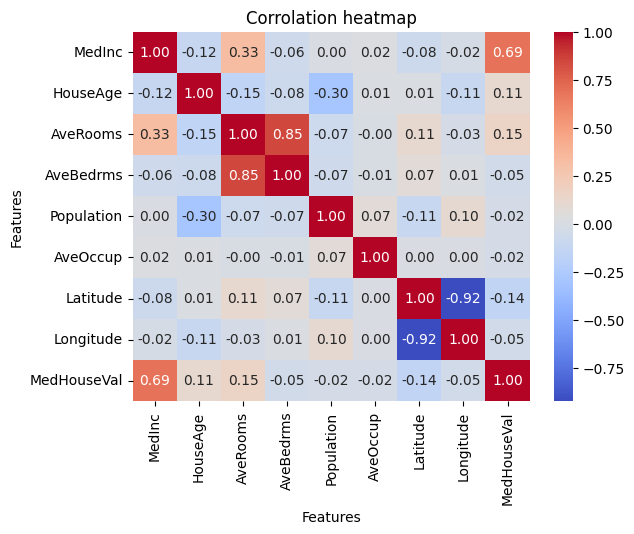

In [264]:
corr_matrix = df.corr()
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Corrolation heatmap")
plt.xlabel("Features")
plt.ylabel("Features")
plt.show()

In [265]:
corr_df = corr_matrix.stack().reset_index()
corr_df.columns = ["feature_1", "feature_2", "corr"]
corr_df

,feature_1,feature_2,corr
0,MedInc,MedInc,1.000000
1,MedInc,HouseAge,-0.119034
2,MedInc,AveRooms,0.326895
3,MedInc,AveBedrms,-0.062040
4,MedInc,Population,0.004834
...,...,...,...
76,MedHouseVal,Population,-0.024650
77,MedHouseVal,AveOccup,-0.023737
78,MedHouseVal,Latitude,-0.144160
79,MedHouseVal,Longitude,-0.045967


In [266]:
corr_df = corr_df[corr_df['feature_1'] < corr_df["feature_2"]].reset_index(drop=True)
corr_df

,feature_1,feature_2,corr
0,MedInc,Population,0.004834
1,HouseAge,MedInc,-0.119034
2,HouseAge,Population,-0.296244
3,HouseAge,Latitude,0.011173
4,HouseAge,Longitude,-0.108197
5,HouseAge,MedHouseVal,0.105623
6,AveRooms,MedInc,0.326895
7,AveRooms,HouseAge,-0.153277
8,AveRooms,Population,-0.072213
9,AveRooms,Latitude,0.106389


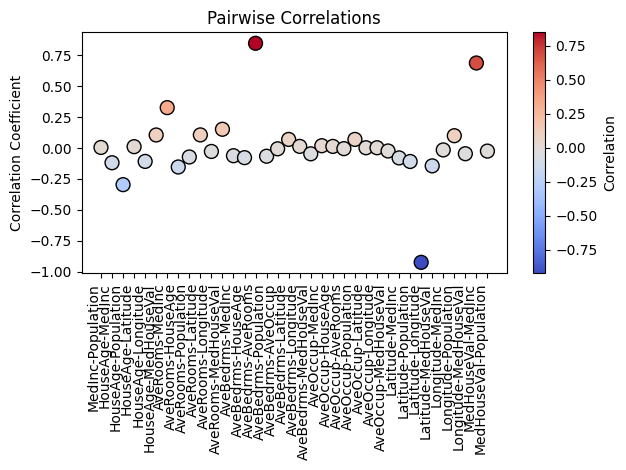

In [267]:
plt.Figure(figsize=(20,6), dpi=300)
plt.scatter(
    range(len(corr_df)),
    corr_df["corr"],
    c=corr_df["corr"],
    cmap="coolwarm",
    s=100, edgecolors="black"
)
plt.xticks(
    ticks=range(len(corr_df["corr"])),
    labels=[f"{a}-{b}" for a, b in zip(corr_df["feature_1"], corr_df["feature_2"])],
    rotation = 90,
    ha = "right"
)

plt.title("Pairwise Correlations")
plt.ylabel("Correlation Coefficient")
plt.colorbar(label="Correlation")
plt.tight_layout()
plt.show()

3. **Data Preprocessing**
   - Split the data into training and test sets (80% train, 20% test) using `train_test_split`.
   - Standardize the features using `StandardScaler` to ensure all features are on the same scale.

In [268]:
X = df.drop(columns=["MedHouseVal"])
y = df["MedHouseVal"]

X_train, X_test, y_train, y_test = train_test_split( X, y, test_size=0.20, random_state=21)

X.shape, y.shape, X_train.shape, y_train.shape, X_test.shape, y_test.shape

((20640, 8), (20640,), (16512, 8), (16512,), (4128, 8), (4128,))

In [269]:
stdsc_mod = StandardScaler()
stdsc_mod.fit(X_train)
X_train_scaled = stdsc_mod.transform(X_train)

4. **Baseline Model**
   - Fit a simple **Linear Regression** model to the training data.
   - Evaluate its performance on the test set using:
     - **Mean Squared Error (MSE)**
     - **R-squared (R²)**

In [270]:
lin_reg_mod = LinearRegression()
lin_reg_mod.fit(X_train_scaled, y_train)
lin_reg_mod.coef_

array([ 0.83335766,  0.1196668 , -0.27415232,  0.31282882, -0.00345446,
       -0.04008608, -0.89303086, -0.86497717])

In [271]:
lin_reg_mod.intercept_

np.float64(2.0671346705426323)

In [272]:
X_test_scaled = stdsc_mod.transform(X_test)

y_test_pred = lin_reg_mod.predict(X_test_scaled)

score_lin_reg = r2_score(y_test, y_test_pred)
mse_lin_reg = mean_squared_error(y_test, y_test_pred)

print("r2_score = ", r2_score(y_test, y_test_pred))
print("mean_squared_error = ", mean_squared_error(y_test, y_test_pred))

r2_score =  0.5971316271519005
mean_squared_error =  0.5416111027038726


5. **Ridge Regression**
   - Apply **Ridge Regression** with different values of the regularization parameter (`alpha`).
   - Use cross-validation to find the optimal `alpha`.
   - Plot the model coefficients as a function of `alpha`.
   - Evaluate the Ridge Regression model and compare it to the baseline model.

In [273]:
rid_reg_mod = Ridge(alpha=1.1)
rid_reg_mod.fit(X_train_scaled, y_train)

print("intercept_ = ", rid_reg_mod.intercept_)
print("coeff_ = ", rid_reg_mod.coef_)

y_test_pred_ridge = rid_reg_mod.predict(X_test_scaled)
print("r2_score = ", r2_score(y_test, y_test_pred_ridge))
print("mean_squared_error = ", mean_squared_error(y_test, y_test_pred_ridge))


score_ridge_reg = r2_score(y_test, y_test_pred_ridge)
mse_ridge_reg = mean_squared_error(y_test, y_test_pred_ridge)

intercept_ =  2.0671346705426323
coeff_ =  [ 0.83331013  0.11975563 -0.27394847  0.31257249 -0.00342155 -0.0400912
 -0.89219766 -0.86413444]
r2_score =  0.5971319576389381
mean_squared_error =  0.5416106584013137


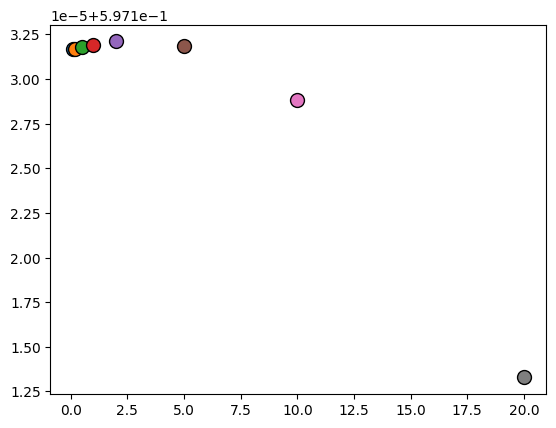

In [274]:
alpha = [0.1, 0.2, 0.5, 1, 2, 5, 10, 20]
for i in alpha:
    rid_reg_mod = Ridge(alpha=i)
    rid_reg_mod.fit(X_train_scaled, y_train)

    y_test_pred_ridge = rid_reg_mod.predict(X_test_scaled)

    score_lin_reg = r2_score(y_test, y_test_pred_ridge)
    mse_lin_reg = mean_squared_error(y_test, y_test_pred_ridge)

    plt.scatter(i, score_lin_reg, edgecolors="black", s=100)
plt.show()


In [275]:
ridcv_reg_mod = RidgeCV(alphas=[0.1, 0.2, 0.5, 1, 2, 5, 10, 20])

ridcv_reg_mod.fit(X_train_scaled, y_train)
y_test_pred_ridgecv = ridcv_reg_mod.predict(X_test_scaled)
score_ridcv = r2_score(y_test, y_test_pred_ridgecv)
print(score_ridcv)



0.5971132774025614


6. **Lasso Regression**
   - Apply **Lasso Regression** with different values of `alpha`.
   - Use cross-validation to find the optimal `alpha`.
   - Plot the model coefficients as a function of `alpha`.
   - Evaluate the Lasso Regression model and compare it to the baseline and Ridge models.

In [276]:
los_reg_mod = Lasso(alpha=0.2)
los_reg_mod.fit(X_train_scaled, y_train)


print("intercept_ = ", los_reg_mod.intercept_)
print("coeff_ = ", los_reg_mod.coef_)

y_test_predict_los = los_reg_mod.predict(X_test_scaled)
print("r2_score = ", r2_score(y_test, y_test_predict_los))
print("mean_squared_error = ", mean_squared_error(y_test, y_test_predict_los))


score_lasso_reg = r2_score(y_test, y_test_predict_los)
mse_lasso_reg = mean_squared_error(y_test, y_test_predict_los)

intercept_ =  2.0671346705426354
coeff_ =  [ 0.59502092  0.         -0.         -0.         -0.         -0.
 -0.         -0.        ]
r2_score =  0.4372255370616245
mean_squared_error =  0.7565868109496873


7. **Model Comparison**
   - Compare the performance of Linear Regression, Ridge Regression, and Lasso Regression in terms of:
     - MSE
     - R²
     - Number of non-zero coefficients in each model (for Lasso).

In [277]:
# score

print("linreg:", score_lin_reg)
print("ridreg:", score_ridge_reg)
print("lasreg:", score_lasso_reg)

linreg: 0.5971132774025435
ridreg: 0.5971319576389381
lasreg: 0.4372255370616245


In [278]:
# mse
print("linreg:", mse_lin_reg)
print("ridreg:", mse_ridge_reg)
print("lasreg:", mse_lasso_reg)

linreg: 0.5416357718728949
ridreg: 0.5416106584013137
lasreg: 0.7565868109496873
